In [1]:
%run generator_benchmark.py
print("Generated perturbation_benchmark.jsonl with 7×500 pairs (3500 total).")

/home/e12217676/miniconda/envs/protoattn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ synonym: 500 pairs (1→250, 2→150, 3→100)
✅ typo: 500 pairs
✅ spelling: 500 pairs
✅ morphology: 500 pairs
✅ contraction: 500 pairs
✅ punctuation: 500 pairs
✅ abbreviation: 500 pairs

🎉 Wrote 3500 pairs to perturbation_benchmark.jsonl
✅ Generated perturbation_benchmark.jsonl with 7×500 pairs (3500 total).


In [2]:
import json, random
from collections import defaultdict

dataset_file = "perturbation_benchmark.jsonl"
with open(dataset_file, "r") as f:
    data = [json.loads(line) for line in f]

by_slice = defaultdict(list)
for ex in data:
    by_slice[ex["slice"]].append(ex)

for slice_name, examples in by_slice.items():
    print(f"\n=== Slice: {slice_name} ({len(examples)} pairs) ===")
    for ex in random.sample(examples, 3):
        print(f" - Original : {ex['original']}")
        print(f"   Perturbed: {ex['perturbed']}")


=== Slice: synonym (500 pairs) ===
 - Original : Really ? My name is Gretchen Hammer . What is your name ?
   Perturbed: Really ? My name be Gretchen Hammer . What is your gens ?
 - Original : You're too strict with yourself .
   Perturbed: You're overly strict with yourself .
 - Original : I enjoy Rock and R & B .
   Perturbed: I enjoy Rock and R & Bel .

=== Slice: typo (500 pairs) ===
 - Original : I'm afraid you can't smoke here .
   Perturbed: I'm afraid you can't saoke here .
 - Original : It doesn't matter .
   Perturbed: It doesn't mattxr .
 - Original : What a surprise ! This is the best present I've ever received .
   Perturbed: Whmt a surprise ! This is the best present I've ever received .

=== Slice: spelling (500 pairs) ===
 - Original : The defense was strong.
   Perturbed: The defence was strong.
 - Original : The defense was strong.
   Perturbed: The defence was strong.
 - Original : The city center is crowded.
   Perturbed: The city centre is crowded.

=== Slice: mor

In [3]:
from spotcheck_and_filter_rebalance import filter_and_rebalance

cleaned, variance = filter_and_rebalance(
    in_file="perturbation_benchmark.jsonl",
    out_file="perturbation_benchmark_clean.jsonl"
)

print("\n=== Variance Report (from notebook) ===")
for slice_name, stats in variance.items():
    print(f"{slice_name}: sim={stats['avg_semantic_sim']:.3f}, "
          f"edit={stats['avg_edit_distance']:.2f}")

✅ synonym: 500 pairs after cleaning
✅ typo: 500 pairs after cleaning
✅ spelling: 500 pairs after cleaning
✅ morphology: 500 pairs after cleaning
✅ contraction: 500 pairs after cleaning
✅ punctuation: 500 pairs after cleaning
✅ abbreviation: 500 pairs after cleaning

🎉 Wrote cleaned dataset with 3500 pairs to perturbation_benchmark_clean.jsonl

=== Variance Report ===
synonym: count=500, avg_sim=0.828, avg_edit=5.89
typo: count=500, avg_sim=0.775, avg_edit=1.03
spelling: count=500, avg_sim=0.956, avg_edit=1.20
morphology: count=500, avg_sim=0.881, avg_edit=1.00
contraction: count=500, avg_sim=0.895, avg_edit=2.54
punctuation: count=500, avg_sim=0.983, avg_edit=1.09
abbreviation: count=500, avg_sim=0.894, avg_edit=7.23

=== Variance Report (from notebook) ===
synonym: sim=0.828, edit=5.89
typo: sim=0.775, edit=1.03
spelling: sim=0.956, edit=1.20
morphology: sim=0.881, edit=1.00
contraction: sim=0.895, edit=2.54
punctuation: sim=0.983, edit=1.09
abbreviation: sim=0.894, edit=7.23


In [4]:
import json, random
from collections import defaultdict

with open("perturbation_benchmark_clean.jsonl") as f:
    cleaned = [json.loads(line) for line in f]

by_slice = defaultdict(list)
for ex in cleaned:
    by_slice[ex["slice"]].append(ex)

# Peek 5 random examples per slice
for slice_name, examples in by_slice.items():
    print(f"\n=== Slice: {slice_name} ({len(examples)} pairs) ===")
    for ex in random.sample(examples, 10):
        print(f" - Original : {ex['original']}")
        print(f"   Perturbed: {ex['perturbed']}")



=== Slice: synonym (500 pairs) ===
 - Original : This room is dark.
   Perturbed: This room is dim.
 - Original : He is polite.
   Perturbed: He is courteous.
 - Original : He is polite.
   Perturbed: He is courteous.
 - Original : The Age of Doom In 1993 six geeks had a digital nightmare that changed the culture
   Perturbed: The Age of Doom inch 1993 six geeks had a digital nightmare that changed the culture
 - Original : She is funny.
   Perturbed: She is comical.
 - Original : He is clever.
   Perturbed: He is bright.
 - Original : She is beautiful.
   Perturbed: She is pretty.
 - Original : The car is quick.
   Perturbed: The car is fast.
 - Original : That answer is wrong.
   Perturbed: That answer is incorrect.
 - Original : This is expensive.
   Perturbed: This is costly.

=== Slice: typo (500 pairs) ===
 - Original : Yes.We will need milk powder and bassinet .
   Perturbed: Yes.We will need milk pjwder and bassinet .
 - Original : Microsoft readies Host Integration Server 200

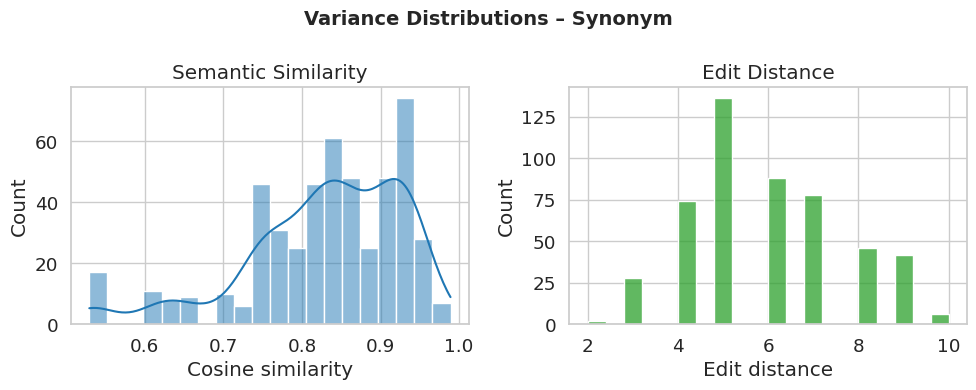

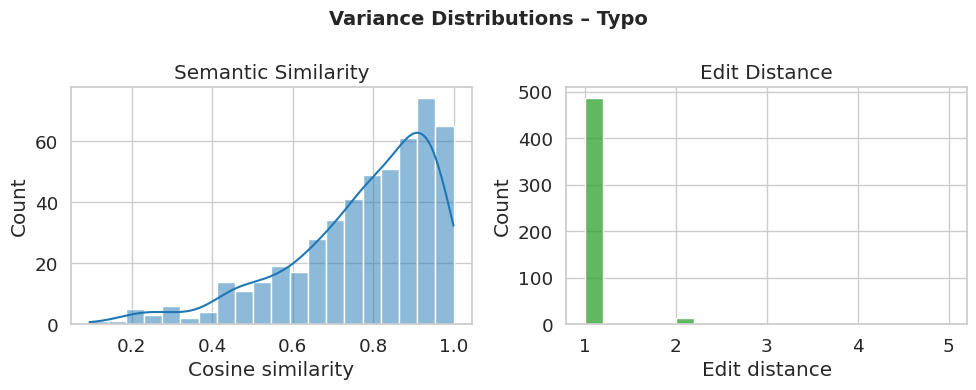

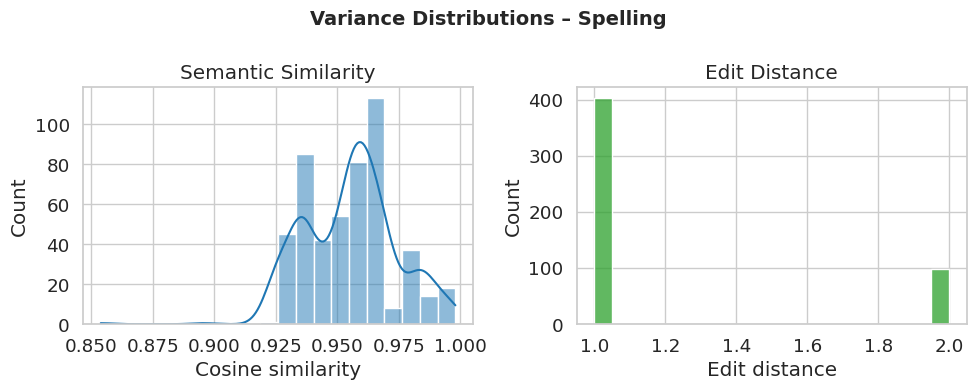

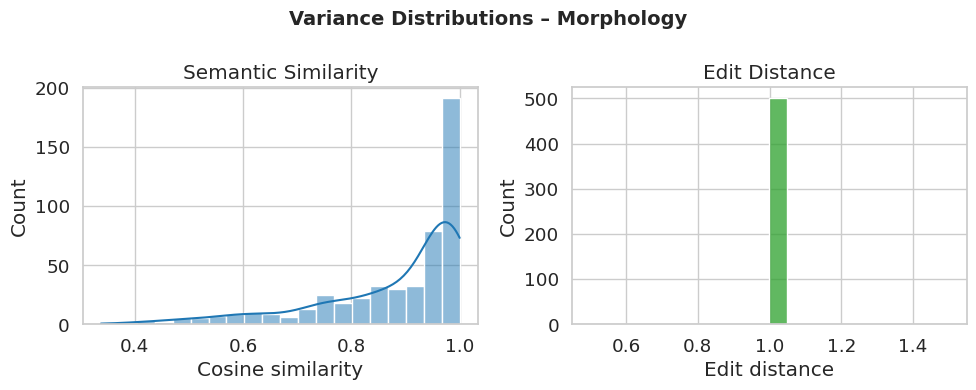

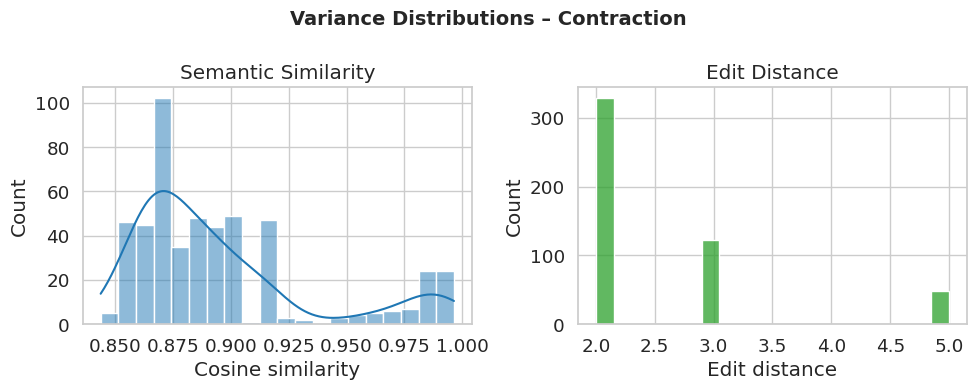

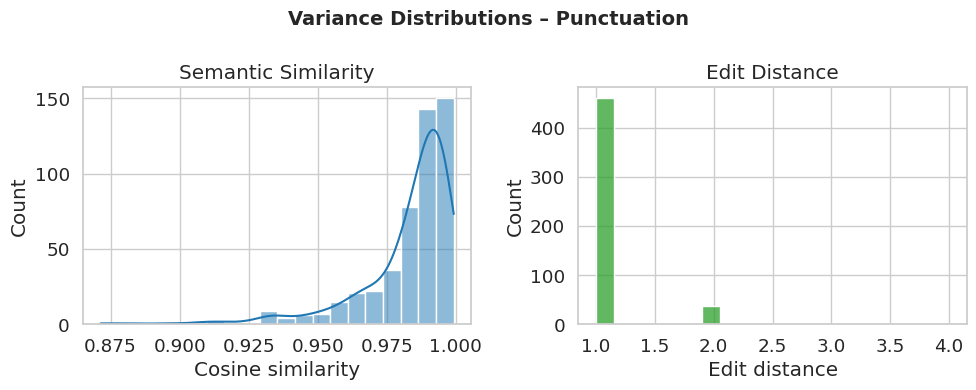

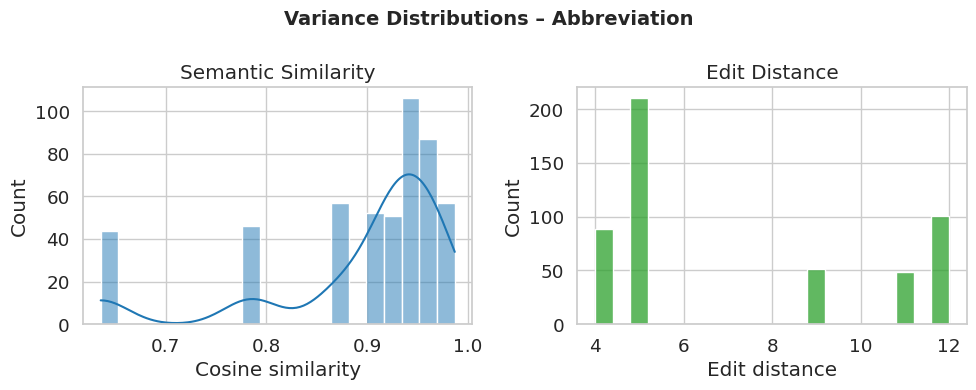

/tmp/ipykernel_3276552/2937439094.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sims, x="Slice", y="Similarity", palette="Set2")


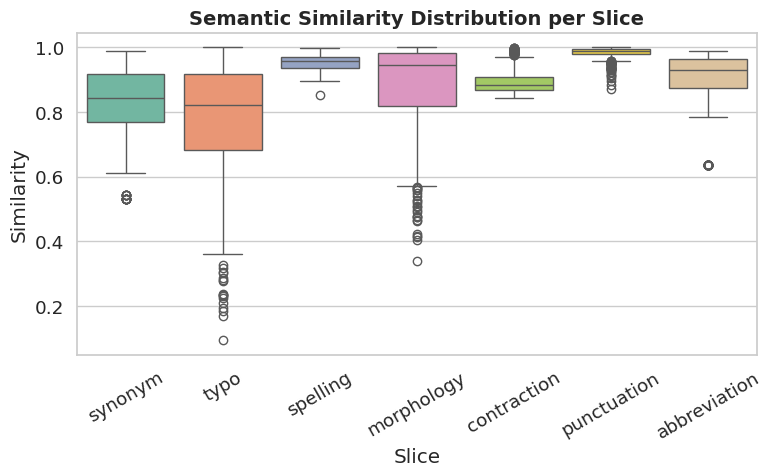

/tmp/ipykernel_3276552/2937439094.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_edits, x="Slice", y="EditDistance", palette="Set3")


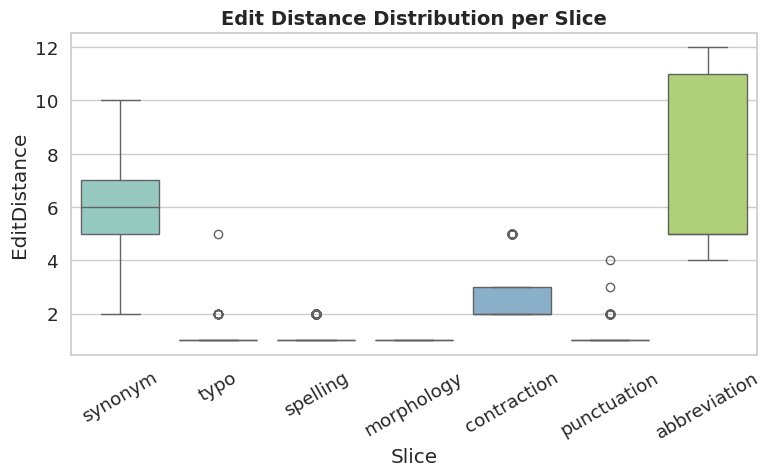

In [5]:
# === Variance visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
import editdistance
from collections import defaultdict
import pandas as pd

# Use clean style
sns.set(style="whitegrid", font_scale=1.2)

model = SentenceTransformer("all-MiniLM-L6-v2")

def compute_distributions(examples):
    originals = [ex["original"] for ex in examples]
    perturbed = [ex["perturbed"] for ex in examples]
    emb1 = model.encode(originals, convert_to_tensor=True, show_progress_bar=False)
    emb2 = model.encode(perturbed, convert_to_tensor=True, show_progress_bar=False)
    sims = util.cos_sim(emb1, emb2).diagonal().tolist()
    edits = [editdistance.eval(o, p) for o, p in zip(originals, perturbed)]
    return sims, edits

# Group cleaned dataset by slice
by_slice = defaultdict(list)
for ex in cleaned:
    by_slice[ex["slice"]].append(ex)

# --- Per-slice histograms ---
for slice_name, examples in by_slice.items():
    sims, edits = compute_distributions(examples)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(sims, bins=20, kde=True, ax=axes[0], color="#1f77b4")
    axes[0].set_title("Semantic Similarity")
    axes[0].set_xlabel("Cosine similarity")
    sns.histplot(edits, bins=20, ax=axes[1], color="#2ca02c")
    axes[1].set_title("Edit Distance")
    axes[1].set_xlabel("Edit distance")
    fig.suptitle(f"Variance Distributions – {slice_name.capitalize()}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

# --- Global boxplots ---
all_sims, all_edits = [], []
for slice_name, examples in by_slice.items():
    sims, edits = compute_distributions(examples)
    all_sims.extend([(slice_name, s) for s in sims])
    all_edits.extend([(slice_name, e) for e in edits])

df_sims = pd.DataFrame(all_sims, columns=["Slice", "Similarity"])
df_edits = pd.DataFrame(all_edits, columns=["Slice", "EditDistance"])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_sims, x="Slice", y="Similarity", palette="Set2")
plt.title("Semantic Similarity Distribution per Slice", fontsize=14, weight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_edits, x="Slice", y="EditDistance", palette="Set3")
plt.title("Edit Distance Distribution per Slice", fontsize=14, weight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
